# Musica

Notebook simple pour entraîner, évaluer et tester le modèle de reconnaissance d'accords.


## 0. Imports

On charge les bibliothèques et les classes utiles.


In [135]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

from musica.modeling import (
    ROOTS,
    ChordEvaluator,
    ChordPredictor,
    ChordTrainer,
    FeatureExtractor,
    MusicaConfig,
    prepare_data,
)

## 1. Configuration

Les paramètres viennent de `musica.toml`.


In [136]:
config = MusicaConfig.load()
config

MusicaConfig(seed=0, epochs=60, batch_size=32, learning_rate=0.001, force_retrain=False, val_ratio=0.15, test_ratio=0.15, sample_rate=22050, target_duration=1.5, hop_length=512, bins_per_octave=12, n_chroma=12, top_k=3, dataset_dir=PosixPath('audio/chords'), logs_dir=PosixPath('logs'), legacy_model_path=PosixPath('logs/best_model.keras'), legacy_params_path=PosixPath('logs/best_model.params.json'), example_audio_path=PosixPath('E_maj.wav'), model_architecture='cnn_chords_chroma_cqt_v1', midi_output_dir=PosixPath('audio/chords/midi'), clean_output_dir=PosixPath('audio/chords/clean'), noise_download_dir=PosixPath('assets/noises/internet'), noisy_output_dir=PosixPath('audio/chords/noisy'), realistic_output_dir=PosixPath('audio/chords/realistic'), transposed_output_dir=PosixPath('audio/chords/transposed'), recorded_audio_dir=PosixPath('audio/chords/recorded'), audio_manifest_path=PosixPath('audio/manifest.csv'), chord_duration=1.5, chord_sample_rate=44100, renderer='auto', soundfont_path=P

## 2. Préparer les données

On charge les WAV, on crée les splits et on extrait les features Chroma-CQT.


In [137]:
prepared = prepare_data(config)

print(f"Volume audio exploitable: {len(prepared.dataset.audio_paths)} fichiers")
print(f"Couverture fonctionnelle: {len(prepared.dataset.labels)} classes d'accords")
print(f"Train: {len(prepared.split.train_paths)} fichiers")
print(f"Validation: {len(prepared.split.val_paths)} fichiers")
print(f"Test: {len(prepared.split.test_paths)} fichiers")
print(f"Features train: {prepared.x_train.shape} | labels: {prepared.y_train.shape}")
print(f"Features validation: {prepared.x_val.shape} | labels: {prepared.y_val.shape}")
print(f"Features test: {prepared.x_test.shape} | labels: {prepared.y_test.shape}")

Volume audio exploitable: 3924 fichiers
Couverture fonctionnelle: 36 classes d'accords
Train: 2772 fichiers
Validation: 576 fichiers
Test: 576 fichiers
Features train: (2772, 65, 12, 1) | labels: (2772,)
Features validation: (576, 65, 12, 1) | labels: (576,)
Features test: (576, 65, 12, 1) | labels: (576,)


## 3. Vérifier les splits

On contrôle rapidement la répartition train / validation / test.


train     : 2772 fichiers | 70.6%
validation:  576 fichiers | 14.7%
test      :  576 fichiers | 14.7%
train     : min 77 | max 77 exemples par classe
validation: min 16 | max 16 exemples par classe
test      : min 16 | max 16 exemples par classe


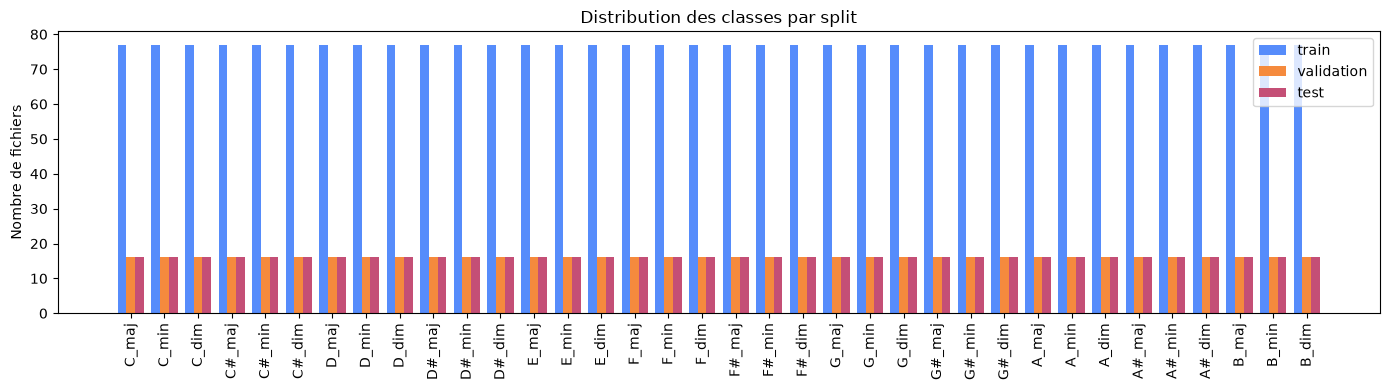

In [138]:
total_files = len(prepared.split.train_paths) + len(prepared.split.val_paths) + len(prepared.split.test_paths)

for name, paths in (
    ("train", prepared.split.train_paths),
    ("validation", prepared.split.val_paths),
    ("test", prepared.split.test_paths),
):
    proportion = len(paths) / total_files
    print(f"{name:10s}: {len(paths):4d} fichiers | {proportion:.1%}")

split_counts = {}
for name, paths in (
    ("train", prepared.split.train_paths),
    ("validation", prepared.split.val_paths),
    ("test", prepared.split.test_paths),
):
    split_counts[name] = np.array([
        sum(prepared.dataset.label_from_path(path) == label for path in paths)
        for label in prepared.dataset.labels
    ])
    print(f"{name:10s}: min {split_counts[name].min()} | max {split_counts[name].max()} exemples par classe")

x = np.arange(len(prepared.dataset.labels))
width = 0.26
plt.figure(figsize=(14, 4))
plt.bar(x - width, split_counts["train"], width, label="train")
plt.bar(x, split_counts["validation"], width, label="validation")
plt.bar(x + width, split_counts["test"], width, label="test")
plt.xticks(x, prepared.dataset.labels, rotation=90)
plt.ylabel("Nombre de fichiers")
plt.title("Distribution des classes par split")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Visualiser une feature

Exemple de représentation Chroma-CQT utilisée par le modèle.


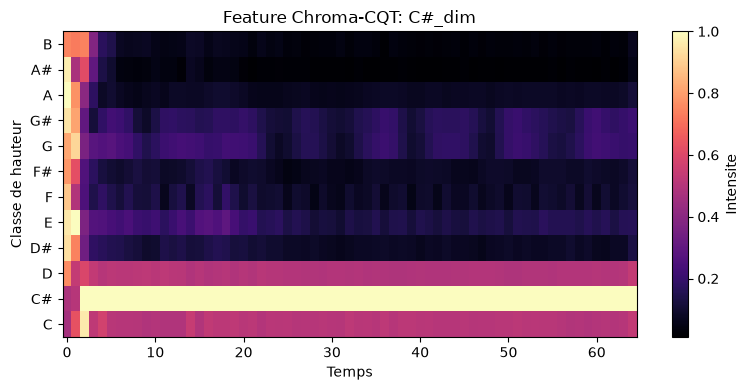

In [139]:
example_index = 0
plt.figure(figsize=(8, 4))
plt.imshow(prepared.x_train[example_index, :, :, 0].T, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Intensite")
plt.yticks(range(config.n_chroma), ROOTS)
plt.xlabel("Temps")
plt.ylabel("Classe de hauteur")
plt.title(f"Feature Chroma-CQT: {prepared.dataset.label_from_path(prepared.split.train_paths[example_index])}")
plt.tight_layout()
plt.show()

## 5. Entraîner le modèle

Le modèle est entraîné ou repris depuis le cache si le run existe déjà.


In [140]:
trainer = ChordTrainer(config, prepared.dataset)
training = trainer.train_or_load(prepared)

print(f"Signature du run: {training.signature}")
print(f"Artefact modele: {training.model_path}")
print(f"Modele reutilise depuis le cache: {training.cache_hit}")


Signature du run: 32cf4e367399
Artefact modele: /Users/raharison/docs/projects/musica/logs/models/32cf4e367399/best_model.keras
Modele reutilise depuis le cache: True


## 6. Courbes d'entraînement

On affiche l'accuracy et la loss.


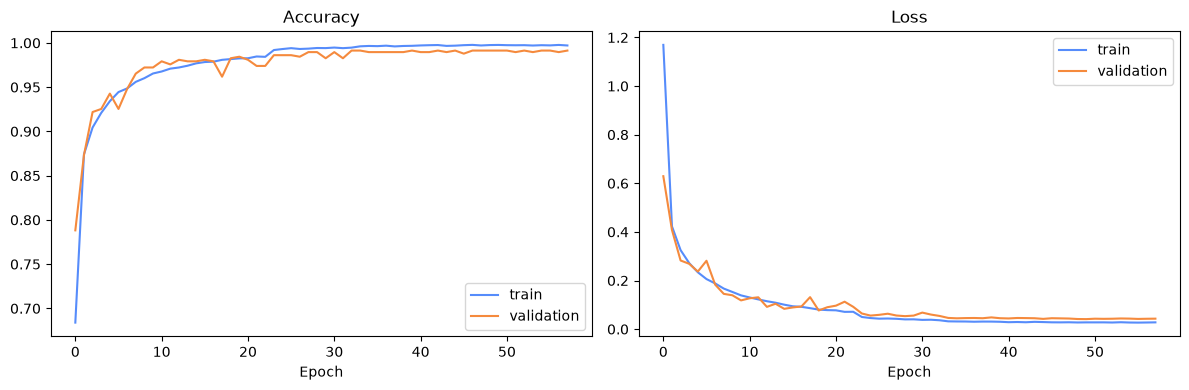

In [141]:
log_data = np.genfromtxt(training.history_log_path, delimiter=",", names=True)
curves = {name: np.atleast_1d(log_data[name]) for name in log_data.dtype.names}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(curves["accuracy"], label="train")
axes[0].plot(curves["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(curves["loss"], label="train")
axes[1].plot(curves["val_loss"], label="validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Évaluer le modèle

On mesure les performances sur le test et on affiche la matrice de confusion.


Accuracy test : 0.9948
Loss test     : 0.0380
F1 macro      : 0.9948
              precision    recall  f1-score   support

       C_maj       1.00      1.00      1.00        16
       C_min       1.00      1.00      1.00        16
       C_dim       1.00      1.00      1.00        16
      C#_maj       1.00      1.00      1.00        16
      C#_min       1.00      1.00      1.00        16
      C#_dim       1.00      1.00      1.00        16
       D_maj       1.00      1.00      1.00        16
       D_min       1.00      0.94      0.97        16
       D_dim       1.00      1.00      1.00        16
      D#_maj       1.00      1.00      1.00        16
      D#_min       1.00      1.00      1.00        16
      D#_dim       1.00      1.00      1.00        16
       E_maj       1.00      1.00      1.00        16
       E_min       1.00      1.00      1.00        16
       E_dim       1.00      1.00      1.00        16
       F_maj       1.00      1.00      1.00        16
       F_min

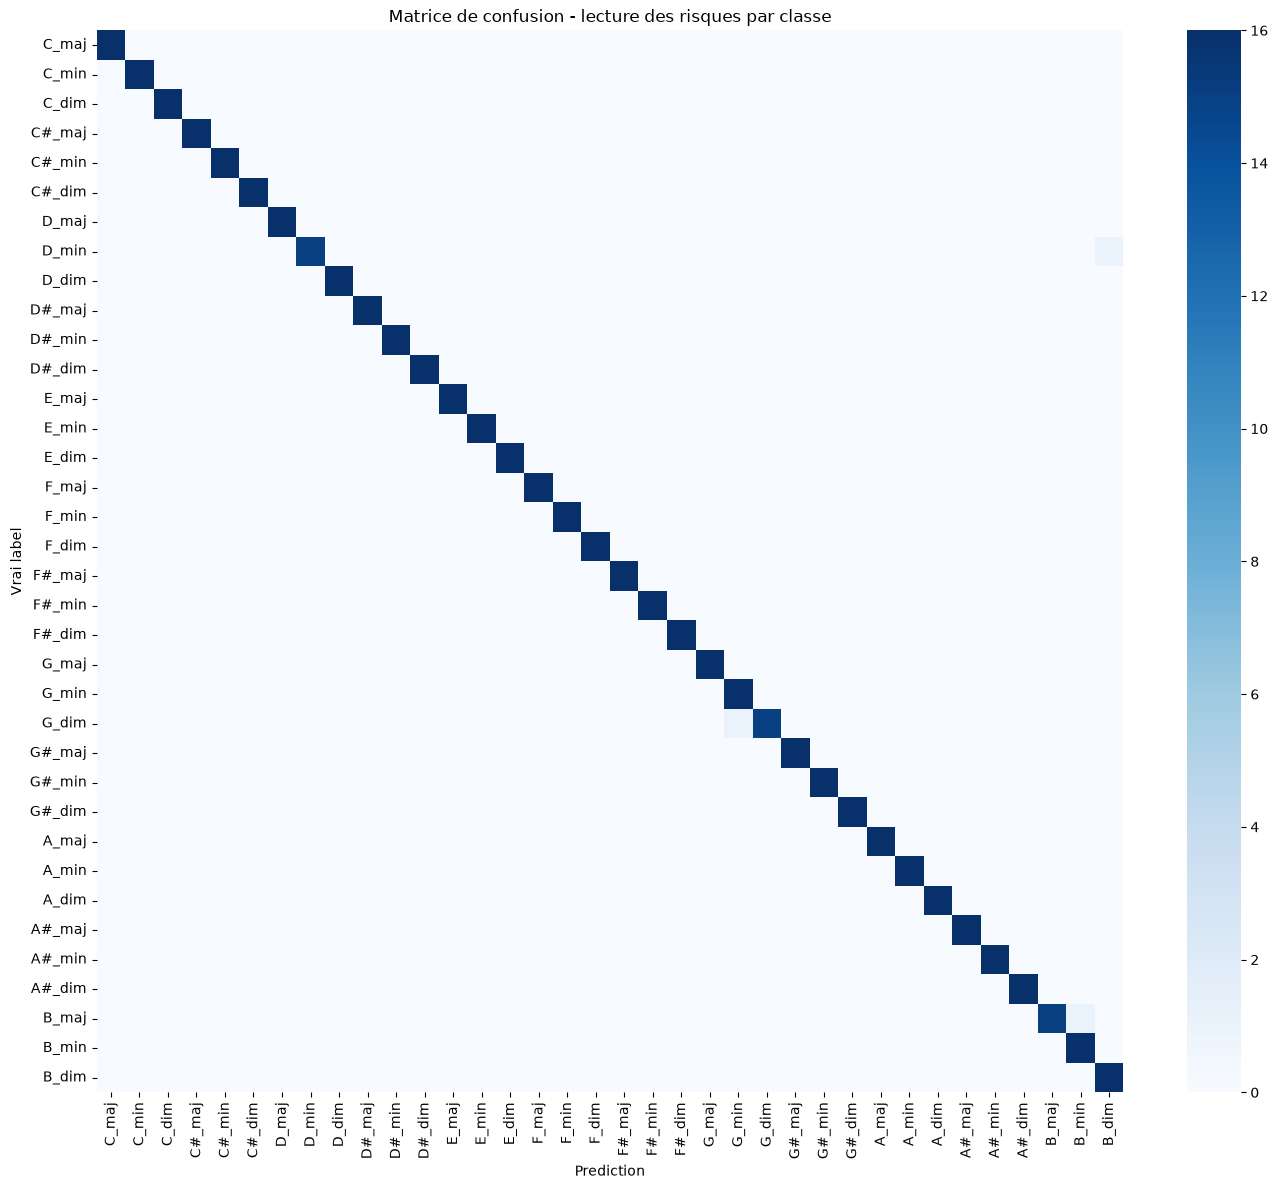

In [142]:
evaluator = ChordEvaluator()
evaluation = evaluator.evaluate(training.model, prepared.x_test, prepared.y_test, prepared.dataset.labels)

y_pred_proba = training.model.predict(prepared.x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(f"Accuracy test : {evaluation.test_accuracy:.4f}")
print(f"Loss test     : {evaluation.test_loss:.4f}")
print(f"F1 macro      : {evaluation.f1_macro:.4f}")
print(evaluation.report)

cm = confusion_matrix(prepared.y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=prepared.dataset.labels, yticklabels=prepared.dataset.labels)
plt.xlabel("Prediction")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion - lecture des risques par classe")
plt.tight_layout()
plt.show()

## 8. Prédire un accord

On teste le modèle sur le fichier audio configuré.


In [143]:
predictor = ChordPredictor(config, FeatureExtractor(config, prepared.dataset), prepared.dataset.labels)
predictions = predictor.predict(training.model)

print(f"Classe attendue: {prepared.dataset.label_from_path(config.example_audio_path)}")
print(f"Classe predite: {predictions[0][0]}")
print(f"Fichier analyse: {config.example_audio_path}")
print("Top predictions:")
for label, probability in predictions:
    print(f"{label:8s} {probability:.3f}")

Classe attendue: E_maj
Classe predite: E_maj
Fichier analyse: E_maj.wav
Top predictions:
E_maj    1.000
A_min    0.000
G#_min   0.000
